# Day 4-03｜籃球軌跡追蹤與出手點估計
> Python 籃球運動資料分析課程  
> 以學生完成轉檔的影片建立球軌跡，並用速度變化估計出手 frame。  
> 修課背景：具備基礎 Python 語法即可；不預設電腦視覺或運動資料分析經驗。

## 學習目標
- 從已轉檔影片讀取影格資料。
- 取得籃球中心點的 frame-by-frame 座標。
- 依據球軌跡與速度變化估計出手 frame。

## 完成產出
- 球軌跡 CSV 與軌跡圖。

## 課堂要求
- 先完成 Day 4-01 的影片上傳與轉檔。
- 按照本單元順序執行各段程式。
- 完成指定輸出後，記錄結果並供課堂討論。


## 執行階段提醒
請優先使用 **GPU** 或 **TPU** 的執行階段；不要使用純 CPU 執行。  
YOLO、MediaPipe 與影片處理在純 CPU 上會明顯較慢，容易讓課堂操作卡住。


## 課程流程
1. 讀取 Day 4-01 產生的 converted 影片。
2. 執行顏色式基準追蹤。
3. 儲存軌跡並判讀出手點。


In [1]:
from pathlib import Path
import subprocess
import sys

COURSE_ROOT_HINT = next(
    (p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (p / "src" / "course_setup.py").exists()),
    Path("/content/basketball_hackathon/course"),
)
if not (COURSE_ROOT_HINT / "src" / "course_setup.py").exists() and "google.colab" in sys.modules:
    COURSE_ROOT_HINT.parent.mkdir(parents=True, exist_ok=True)
    subprocess.run([
        "git", "clone", "--depth", "1", "https://github.com/henry753951/basketball-hackathon-course.git", str(COURSE_ROOT_HINT)
    ], check=True)
if str(COURSE_ROOT_HINT) not in sys.path:
    sys.path.insert(0, str(COURSE_ROOT_HINT))

from src.course_setup import bootstrap_course_repo  # noqa: E402

COURSE_ROOT = bootstrap_course_repo(preferred=COURSE_ROOT_HINT)


課程根目錄: H:\Repos\basketball-hackathon-course
素材資料夾: H:\Repos\basketball-hackathon-course\assets
工具模組: H:\Repos\basketball-hackathon-course\src


In [2]:
from src.video_utils import pick_first_converted_video
from src.shooting_utils import track_orange_ball, estimate_release_frame
from src.plot_utils import plot_ball_path

video_path = pick_first_converted_video(COURSE_ROOT)
print("video_path:", video_path)


video_path: H:\Repos\basketball-hackathon-course\assets\converted\video_001.mp4


In [3]:
ball_df = track_orange_ball(video_path, max_frames=180)
if ball_df.empty:
    raise RuntimeError(
        "沒有追蹤到任何籃球軌跡點。請確認影片中的籃球顏色、亮度，"
        "或調整 src.shooting_utils.track_orange_ball 的 HSV 範圍。"
    )

print("tracked points:", len(ball_df))
ball_df.head()


tracked points: 180


,frame,x,y,area,vx,vy,speed
0,0,634.360620,668.386890,3933.5,NaN,NaN,0.000000
1,1,634.184460,668.346509,3934.0,-0.176160,-0.040381,0.180729
2,2,633.575773,668.214909,3935.0,-0.608687,-0.131600,0.622751
3,3,633.575773,668.214909,3935.0,0.000000,0.000000,0.000000
4,4,633.499155,668.214799,3944.0,-0.076618,-0.000110,0.076618


saved: H:\Repos\basketball-hackathon-course\assets\results\d4_03_ball_track.csv


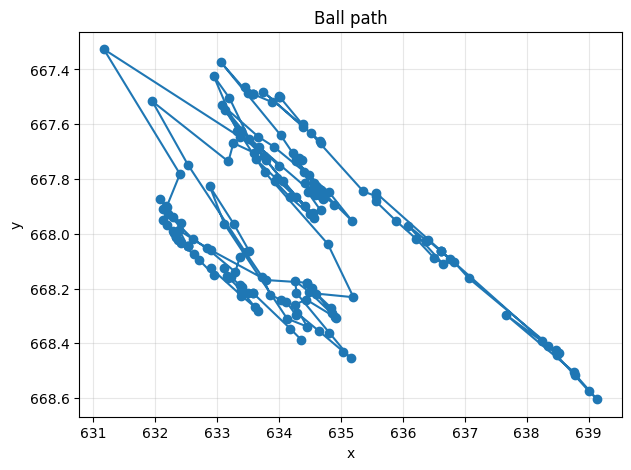

estimated release frame: 154


In [4]:
out_csv = COURSE_ROOT / "assets" / "results" / "d4_03_ball_track.csv"
out_csv.parent.mkdir(parents=True, exist_ok=True)
ball_df.to_csv(out_csv, index=False)
print("saved:", out_csv)

plot_ball_path(
    ball_df, output_path=COURSE_ROOT / "assets" / "results" / "d4_03_ball_path.png"
)
release_frame = estimate_release_frame(ball_df)
print("estimated release frame:", release_frame)


## 模型選擇

本單元的 `track_orange_ball` 是顏色式基準方法，只適合用來說明「逐影格取得球中心點」的資料格式。在正式專案中，籃球追蹤建議分成兩層：

- 偵測模型：使用 Ultralytics YOLO 類型的 object detector，類別至少包含 `ball`；若任務需要判斷進球，可另外標註 `ball-in-basket`、rim 或 backboard。
- 時序追蹤：將每一 frame 的 ball detection 交給 ByteTrack 或 BoT-SORT 進行關聯；短暫漏偵可再用插值補齊。

球在籃球影片中通常很小，且容易被手部或身體遮擋。訓練資料應包含不同拍攝角度、球衣顏色、場地光線與壓縮品質，並優先檢查高解析度 frame 的偵測效果。


## 本單元產出檔案

- `assets/results/d4_03_ball_track.csv`：球中心點與軌跡資料。
- `assets/results/d4_03_ball_path.png`：球軌跡圖。
